In [18]:

import multiprocessing

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
from scipy.optimize import curve_fit
from scipy.stats import norm
from pytensor.tensor import erf

In [2]:
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "figure.figsize": (5.8, 3.6),  # tipico per colonna singola
    "lines.linewidth": 1.2,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
})

In [473]:
ENERGY_RANGE = (0, 3000)
BIN_WIDTH = 0.1

BACKGROUND_PEAKS = {
   "???" : 860.45,
    "207Tl": 897.77,
    "228Ac": 911.204,
}

FIT_WINDOW = 6

'''
SIGNAL = {
    "mu": 871,
    "roi": (840, 920),
}'''

SIGNAL = {
    "mu": 871,
    "roi": (800, 950),
}

SAMPLING_CONFIG = {
    "draws": 2000,
    "tune": 2000,
    "chains": 4,
    "target_accept": 0.95,
}


In [474]:
# ============================================================
# ENERGY RESOLUTION
# ============================================================
def sigma_fun(E):
    """
    Detector energy resolution model.
    Returns sigma in keV.
    """
    A = 3.68436e1
    B = 1.72714e4

    return (E * np.sqrt(A / E + B / E**2)) / 2.355 / 100
    


In [475]:

def add_peak(ax, x, text, y_text, y_line_top=60):
    """
    ax       : axis
    x        : posizione del picco (keV)
    text     : label da scrivere
    y_text   : posizione testo
    y_line_top : altezza linea verticale
    """

    # linea verticale tratteggiata
    ax.vlines(
        x,
        0,
        y_line_top,
        ls='--',
        color='black',
        alpha=0.75
    )

    # annotazione (ruotata come nel tuo esempio)
    ax.annotate(
        text,
        xy=(x - 2, y_text),
        rotation=90,
        fontsize=11
    )

In [476]:

# ============================================================
# DATA LOADING
# ============================================================
def load_spectrum(file_path, calibration, energy_range=(0, 3000)):
    """
    Load raw spectrum and convert channels to energy.
    """

    data = pd.read_csv(file_path, header=None)
    spectrum = data[0].to_numpy(dtype=np.float64)

    channels = np.arange(len(spectrum))

    E = (
        channels * calibration["a"]
        + calibration["b"]
        + calibration["c"] * channels**2
    )

    mask = (E >= energy_range[0]) & (E <= energy_range[1])

    return E[mask], spectrum[mask]

In [477]:
# ============================================================
# HISTOGRAMMING
# ============================================================
def make_histogram(E, spectrum, bins):
    counts, edges = np.histogram(E, bins=bins, weights=spectrum)
    centers = 0.5 * (edges[1:] + edges[:-1])

    return centers, counts



In [478]:

# ============================================================
# GAUSSIAN MODEL
# ============================================================
def gaussian_plus_bg(E, mu, sigma, area, background):
    """
    Gaussian normalized to total area + flat background.
    """

    gaussian = (
        area
        / (sigma * np.sqrt(2 * np.pi))
        * np.exp(-0.5 * ((E - mu) / sigma) ** 2)
    )

    return gaussian + background


In [479]:
# ============================================================
# PEAK FITTING
# ============================================================
def fit_peak(E, counts, center, window=4, plot=True):
    """
    Fit a Gaussian peak + constant background.
    """

    mask = (E > center - window) & (E < center + window)

    E_roi = E[mask]
    counts_roi = counts[mask]

    sigma_guess = sigma_fun(center)

    p0 = [
        center,
        sigma_guess,
        np.sum(counts_roi),
        np.median(counts_roi),
    ]

    bounds = (
        [center - 1, 0.01, 0, 0],
        [center + 1, 10, np.inf, np.inf],
    )

    popt, pcov = curve_fit(
        gaussian_plus_bg,
        E_roi,
        counts_roi,
        p0=p0,
        bounds=bounds,
        #sigma=np.sqrt(counts_roi),
        maxfev=10000,
    )

    perr = np.sqrt(np.diag(pcov))

    result = {
        "mu": popt[0],
        "sigma": popt[1],
        "N": popt[2],
        "B": popt[3],
        "err_mu": perr[0],
        "err_sigma": perr[1],
        "err_N": perr[2],
        "err_B": perr[3],
    }

    if plot:
        fig, ax = plt.subplots(
            2,
            1,
            figsize=(7, 6),
            sharex=True,
            gridspec_kw={"height_ratios": [3, 1]},
        )

        E_fit = np.linspace(E_roi.min(), E_roi.max(), 400)
        model_fit = gaussian_plus_bg(E_fit, *popt)

        ax[0].step(E_roi, counts_roi, where="mid", color="black", label="Data")
        ax[0].plot(E_fit, model_fit, color="red", lw=2, label="Fit")

        ax[0].set_ylabel(f"Counts / {E_roi[1]-E_roi[0]:.2f} keV")
        ax[0].set_title(f"Peak @ {center:.2f} keV")
        ax[0].legend()
        ax[0].grid(alpha=0.3)

        residuals = counts_roi - gaussian_plus_bg(E_roi, *popt)

        ax[1].scatter(E_roi, residuals, s=15)
        ax[1].axhline(0, color="red")
        ax[1].set_xlabel("Energy [keV]")
        ax[1].set_ylabel("Residuals")
        ax[1].grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

    return result


In [480]:

# ============================================================
# BUILD TOTAL DATASET
# ============================================================
def build_total_spectrum(files_config, bins):
    all_histograms = []
    total_time = 0

    for key, cfg in files_config.items():
        E, spectrum = load_spectrum(
            cfg["path"],
            cfg["calibration"],
            ENERGY_RANGE,
        )

        E_centers, counts = make_histogram(E, spectrum, bins)

        all_histograms.append(counts)
        total_time += cfg["time"]

    total_counts = np.sum(all_histograms, axis=0)

    return E_centers, total_counts, total_time

# inizio

In [481]:
# ============================================================
# CONFIGURATION
# ============================================================
FILES = {
    "50d": {
        "path": "csv-files/zro2_white&green_ 50_days.csv",
        "time": 4279386,
        "calibration": {
            "a": 0.357304,
            "b": -0.295444,
            "c": 1.352297e-9,
        },
    },
    "60d": {
        "path": "csv-files/run3.csv",
        "time": 5151460,
        "calibration": {
            "a": 4.17351849e-01,
            "b": 5.03999145e-01,
            "c": 1.19722147e-07,
        },
    },
}

In [482]:
# ============================================================
# MAIN DATA PREPARATION
# ============================================================
BINS = np.arange(
    ENERGY_RANGE[0],
    ENERGY_RANGE[1] + BIN_WIDTH,
    BIN_WIDTH
)

E_tot, Ntot, t_tot = build_total_spectrum(FILES, BINS)

print(
    f"Total counts = {np.sum(Ntot):.0f} "
    f"in {t_tot / (60 * 60 * 24):.1f} days"
)


Total counts = 24456 in 109.2 days


In [483]:
FILES['50d']['path']

'csv-files/zro2_white&green_ 50_days.csv'

In [484]:
ENERGY_RANGE = (0, 3000)


SIGNAL = {
    "mu": 778.2,
    "roi": (748, 810),
}

SAMPLING_CONFIG = {
    "draws": 2000,
    "tune": 2000,
    "chains": 4,
    "target_accept": 0.95,
}


In [485]:
BACKGROUND_PEAKS = {
    "95Zr": {"E": 756.73, "N": 6.5},
    "214Bi": {"E": 768.4, "N": 5.11},
    "95Nb": {"E": 765.8, "N": 18},
    #"65Zr" : {"E": 770.62, "N" : 0},
    #"214Pb+212Bi": {"E": 785.95, "N": 3.33},
    #"228Ac-supp" :  {"E": 781.9, "N": 3.33},
    '???': {"E": 784.5, "N" : 0},
    "228Ac": {"E": 794.947, "N": 3.55},
}

In [486]:
roi_mask = (
    (E_tot > SIGNAL["roi"][0]) &
    (E_tot < SIGNAL["roi"][1])
)

E_roi = E_tot[roi_mask]
counts_roi = Ntot[roi_mask]

In [487]:


# ============================================================
# BINNING
# ============================================================
bin_edges = BINS
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# ============================================================
# ROI SELECTION (SAFE: on bin centers)
# ============================================================
roi_mask = (
    (bin_centers >= SIGNAL["roi"][0]) &
    (bin_centers <= SIGNAL["roi"][1])
)

counts_roi = Ntot[roi_mask]

idx = np.where(roi_mask)[0]
bin_edges_roi = bin_edges[idx[0]:idx[-1] + 2]


In [488]:


edges_low = bin_edges_roi[:-1]
edges_high = bin_edges_roi[1:]

# ============================================================
# CDF GAUSSIAN (PyTensor safe)
# ============================================================
def gaussian_cdf(x, mu, sigma):
    return 0.5 * (1.0 + pt.erf((x - mu) / (sigma * pt.sqrt(2.0))))

def bin_integral(mu, sigma, low, high):
    return gaussian_cdf(high, mu, sigma) - gaussian_cdf(low, mu, sigma)

# ============================================================
# MODEL
# ============================================================
with pm.Model() as model:

    # ========================================================
    # BACKGROUND PEAKS
    # ========================================================
    A_bg = []
    mu_bg = []

    for name in BACKGROUND_PEAKS:

        fit = BACKGROUND_PEAKS[name]

        A = pm.HalfNormal(f"A_{name}", sigma=np.max(counts_roi)/2)
        mu = pm.Normal(f"mu_{name}", mu=fit["E"], sigma=0.5)

        A_bg.append(A)
        mu_bg.append(mu)

    A_bg = pt.stack(A_bg)
    mu_bg = pt.stack(mu_bg)

    # ========================================================
    # SIGNAL
    # ========================================================
    A_signal = pm.HalfNormal("A_signal", sigma=np.max(counts_roi))

    mu_signal = pm.Normal("mu_signal", mu=SIGNAL["mu"], sigma=0.5)

    sigma = sigma_fun(mu_signal)  # must be PyTensor-compatible

    # ========================================================
    # FLAT BACKGROUND
    # ========================================================
    bin_width = edges_high - edges_low

    Q = pm.Exponential(
        "Q",
        lam=1/np.mean(counts_roi)
    )

    Q_bins = Q * bin_width

    # ========================================================
    # EXACT BIN INTEGRALS
    # ========================================================
    sig = bin_integral(mu_signal, sigma, edges_low, edges_high)

    bg = pt.stack([
        bin_integral(mu_bg[i], sigma, edges_low, edges_high)
        for i in range(len(BACKGROUND_PEAKS))
    ])

    # ========================================================
    # EXPECTATION PER BIN
    # ========================================================
    lambda_E = (
        Q_bins
        + A_signal * sig
        + pt.sum(A_bg[:, None] * bg, axis=0)
    )

    lambda_E = pt.clip(lambda_E, 1e-9, np.inf)

    # ========================================================
    # LIKELIHOOD
    # ========================================================
    pm.Poisson(
        "obs",
        mu=lambda_E,
        observed=counts_roi
    )

    # ========================================================
    # SAMPLING
    # ========================================================
    trace = pm.sample(
        draws=2000,
        tune=1000,
        chains=4,
        cores=min(4, multiprocessing.cpu_count()),
        target_accept=0.95,
        init="jitter+adapt_diag",
        return_inferencedata=True
    )


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [A_95Zr, mu_95Zr, A_214Bi, mu_214Bi, A_95Nb, mu_95Nb, A_???, mu_???, A_228Ac, mu_228Ac, A_signal, mu_signal, Q]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 15 seconds.


In [489]:
summary = az.summary(trace, round_to=4)
summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_95Zr,756.7719,0.3653,756.1022,757.4732,0.0037,0.0049,10047.5359,5213.0985,1.0002
mu_214Bi,767.9723,0.3882,767.2333,768.6924,0.0041,0.0051,9307.1010,5776.4499,1.0002
mu_95Nb,765.5623,0.2893,765.0210,766.1009,0.0031,0.0032,8883.4325,6284.0036,1.0000
mu_???,784.5415,0.3478,783.8885,785.2021,0.0036,0.0048,9726.2387,5212.3737,1.0022
mu_228Ac,794.8228,0.3971,794.0940,795.5764,0.0038,0.0048,10930.1803,5799.9398,1.0003
mu_signal,778.2073,0.4708,777.3012,779.0762,0.0044,0.0060,11247.8554,5190.6224,1.0009
A_95Zr,10.5932,3.7586,3.9042,18.0054,0.0426,0.0455,7074.6981,3412.2254,1.0003
A_214Bi,12.8562,4.1454,4.9746,20.6075,0.0563,0.0697,5589.7012,2419.5132,1.0006
A_95Nb,18.0358,4.0342,10.6898,25.7901,0.0401,0.0507,9880.4139,4731.7814,1.0001
A_???,7.1592,3.4219,0.5566,13.0812,0.0435,0.0390,5405.8155,2780.8377,1.0009


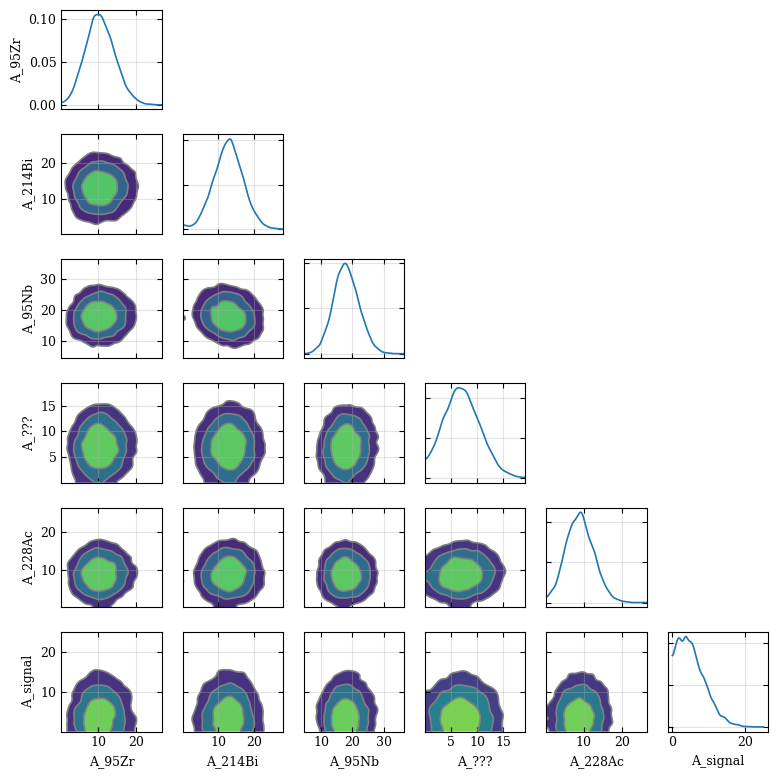

In [490]:

# ============================================================
# CORRELATION PLOTS
# ============================================================
A_vars = [v for v in trace.posterior.data_vars if v.startswith("A_")]

axes = az.plot_pair(
    trace,
    var_names=A_vars,
    kind="kde",
    marginals=True,
    figsize=(8, 8),
    textsize=9,
)

for ax in axes.flatten():
    ax.grid(alpha=0.35)

plt.tight_layout()
plt.show()


In [491]:


# ============================================================
# POSTERIOR OF SIGNAL
# ============================================================
signal_samples = trace.posterior["A_signal"].values.flatten()

N_signal_90 = np.percentile(signal_samples, 90)
N_signal_95 = np.percentile(signal_samples, 95)

print()
print("=" * 60)
print(f"90% upper limit on signal counts : {N_signal_90:.3f}")
print(f"95% upper limit on signal counts : {N_signal_95:.3f}")
print("=" * 60)


90% upper limit on signal counts : 10.692
95% upper limit on signal counts : 12.459


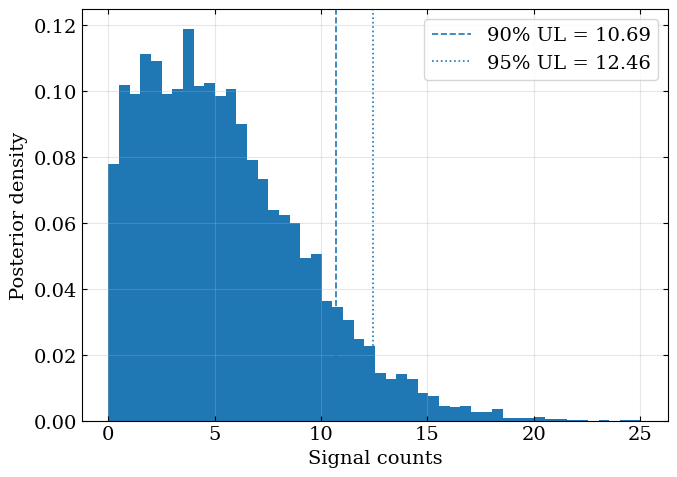

In [492]:
# ============================================================
# SIGNAL POSTERIOR PLOT
# ============================================================
plt.figure(figsize=(7, 5))

plt.hist(signal_samples, bins=50, density=True)

plt.axvline(
    N_signal_90,
    linestyle="--",
    label=f"90% UL = {N_signal_90:.2f}",
)

plt.axvline(
    N_signal_95,
    linestyle=":",
    label=f"95% UL = {N_signal_95:.2f}",
)

plt.xlabel("Signal counts")
plt.ylabel("Posterior density")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()



In [493]:
background_names = list(BACKGROUND_PEAKS.keys())

background_energies = np.array([
    BACKGROUND_PEAKS[name]["E"] for name in background_names
])

background_sigmas = sigma_fun(background_energies)


In [494]:
idata = trace
posterior = idata.posterior

Q_s        = posterior["Q"].values.reshape(-1)
A_signal_s = posterior["A_signal"].values.reshape(-1)
mu_signal_s = posterior["mu_signal"].values.reshape(-1)

A_bg_s = {
    name: posterior[f"A_{name}"].values.reshape(-1)
    for name in background_names
}

mu_bg_s = {
    name: posterior[f"mu_{name}"].values.reshape(-1)
    for name in background_names
}

# ============================================================
# GRID
# ============================================================
bin_centers = 0.5 * (BINS[:-1] + BINS[1:])

roi_mask = (
    (bin_centers >= SIGNAL["roi"][0]) &
    (bin_centers <= SIGNAL["roi"][1])
)

E_roi = bin_centers[roi_mask]
counts_roi = Ntot[roi_mask]

E_fine = np.linspace(E_roi.min(), E_roi.max(), 3000)

# ============================================================
# GAUSSIAN
# ============================================================
def gaussian(x, mu, sigma):
    return (1.0 / (np.sqrt(2*np.pi) * sigma)) * np.exp(
        -0.5 * ((x - mu) / sigma) ** 2
    )

# ============================================================
# MODEL BUILDER (TOTAL)
# ============================================================
def build_total(E, i):
    sigma_i = sigma_fun(mu_signal_s[i])

    lam = (Q_s[i] * BIN_WIDTH) * np.ones_like(E)

    for name in background_names:
        mu_i = mu_bg_s[name][i]
        lam += A_bg_s[name][i] * gaussian(E, mu_i, sigma_i)

    lam += A_signal_s[i] * gaussian(E, mu_signal_s[i], sigma_i)

    return lam

# ============================================================
# MODEL BUILDER (BACKGROUND ONLY)
# ============================================================
def build_background(E, i):
    sigma_i = sigma_fun(mu_signal_s[i])

    lam = (Q_s[i] * BIN_WIDTH) * np.ones_like(E)

    for name in background_names:
        mu_i = mu_bg_s[name][i]
        lam += A_bg_s[name][i] * gaussian(E, mu_i, sigma_i)

    return lam

# ============================================================
# DRAW (ROI + FINE)
# ============================================================
lambda_draws = np.array([
    build_total(E_roi, i)
    for i in range(len(Q_s))
])

lambda_fine_draws = np.array([
    build_total(E_fine, i)
    for i in range(len(Q_s))
])

lambda_bkg_fine_draws = np.array([
    build_background(E_fine, i)
    for i in range(len(Q_s))
])

# ============================================================
# STATISTICS TOTAL (ROI)
# ============================================================
lambda_mean = lambda_draws.mean(axis=0)
lambda_low  = np.percentile(lambda_draws, 5, axis=0)
lambda_high = np.percentile(lambda_draws, 95, axis=0)

# ============================================================
# STATISTICS TOTAL (FINE)
# ============================================================
lambda_fine_mean = lambda_fine_draws.mean(axis=0)

# ============================================================
# STATISTICS BACKGROUND (FINE)
# ============================================================
lambda_bkg_fine_mean = lambda_bkg_fine_draws.mean(axis=0)
lambda_bkg_fine_low  = np.percentile(lambda_bkg_fine_draws, 5, axis=0)
lambda_bkg_fine_high = np.percentile(lambda_bkg_fine_draws, 95, axis=0)

# ============================================================
# SIGNAL LIMIT
# ============================================================
N_signal_90 = np.percentile(A_signal_s, 90)
print("A_signal 90% upper limit:", N_signal_90)

# ============================================================
# RESIDUALS
# ============================================================
residuals = (counts_roi - lambda_mean) / np.sqrt(lambda_mean + 1e-9)

A_signal 90% upper limit: 10.692321482756045


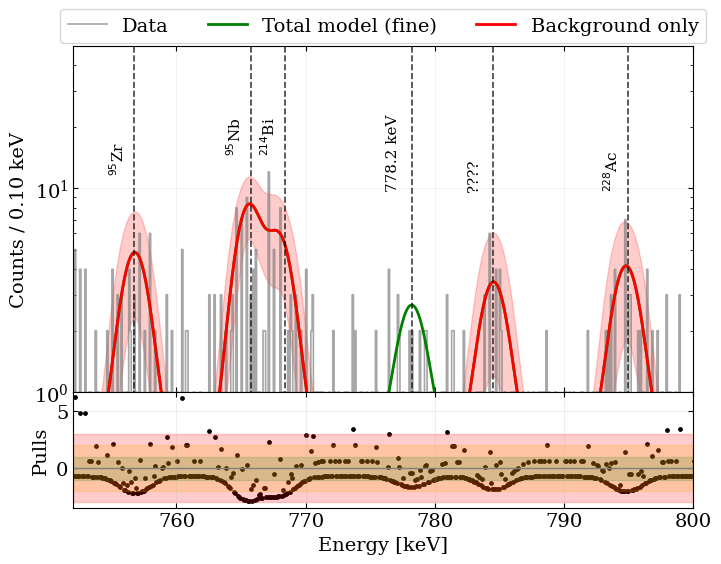

In [495]:
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
    figsize=(8, 6)
)

# ============================================================
# DATA
# ============================================================
ax1.step(E_roi, counts_roi, where='mid', color='grey', alpha=0.7, label='Data')


ax1.plot(E_fine, lambda_fine_mean, color='green', lw=2, label='Total model (fine)')

# ============================================================
# BACKGROUND ONLY (CORRECT!)
# ============================================================
ax1.plot(
    E_fine,
    lambda_bkg_fine_mean,
    color='red',
    lw=2,
    label='Background only'
)

ax1.fill_between(
    E_fine,
    lambda_bkg_fine_low,
    lambda_bkg_fine_high,
    color='red',
    alpha=0.2
)

# ============================================================
# AXES
# ============================================================
ax1.set_yscale('log')
ax1.set_ylim(1, 50)
ax1.set_xlim(752, 800)

ax1.set_ylabel(f"Counts / {E_roi[1]-E_roi[0]:.2f} keV")

ax1.grid(alpha=0.15)

ax1.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 0.98),
    ncol=3
)
add_peak(ax1, 778.2, r"778.2 keV", 10)
add_peak(ax1, 756.73, r"$^{95}$Zr", 12)
add_peak(ax1, 765.8, r"$^{95}$Nb", 15)
add_peak(ax1, 768.4, r"$^{214}$Bi", 15)
add_peak(ax1, 784.5, r"????", 10)
add_peak(ax1, 794.947, r"$^{228}$Ac", 10)
# ============================================================
# RESIDUALS
# ============================================================
ax2.scatter(E_roi, residuals, s=6, color='black')

ax2.axhspan(-3, 3, color='red', alpha=0.2)
ax2.axhspan(-2, 2, color='orange', alpha=0.2)
ax2.axhspan(-1, 1, color='green', alpha=0.15)
ax2.axhline(0, color='gray', lw=1)

ax2.set_xlabel("Energy [keV]")
ax2.set_ylabel("Pulls")
ax2.grid(alpha=0.2)

plt.subplots_adjust(hspace=0)
plt.show()

# half life

In [496]:
# Dati campione
m_sample = 551.3        # massa ZrO2 in grammi
Mr_sample = 123.22      # massa molare ZrO2 [g/mol]
N_A = 6.022e23          # numero di Avogadro
eff_96Zr = 0.024131    # efficienza di rivelazione
i_a_96Zr = 0.0280     # abbondanza isotopica
t_live =    t_tot/(60*60*24*365)             # 90 giorni in anni


# Numero di nuclei 96Zr nel campione
N_nuclei = (m_sample * i_a_96Zr / Mr_sample) * N_A


In [497]:
N_signal_90

np.float64(10.692321482756045)

In [500]:

percentile = 90

T_half_limit = (np.log(2) * N_nuclei * eff_96Zr * t_live) / N_signal_90
print(f"T1/2 > {T_half_limit:.2e} yrs at {percentile}%")

T1/2 > 3.53e+19 yrs at 90%


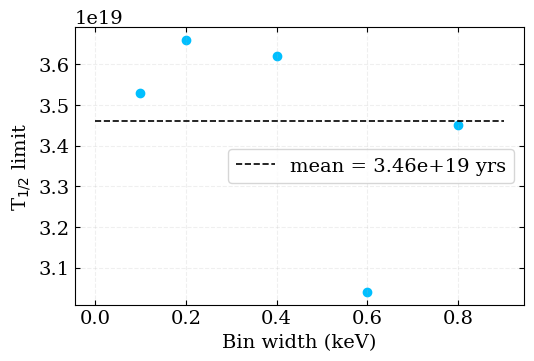

In [514]:
limit = [3.53e19, # 0.1 keV,
3.66e19, # 0.2 keV,
3.62e19, # 0.4,
3.04e19, #0.6
3.45e19 ]# 0.8]

bin_width = [0.1,0.2,0.4,0.6,0.8]

plt.scatter(bin_width, limit, color = 'deepskyblue')
plt.hlines(np.mean(limit), min(bin_width)-0.1, max(bin_width)+0.1, color = 'black', ls = '--', label = f"mean = {np.mean(limit):.2e} yrs")
plt.ylabel(fr"T$_{{1/2}}$ limit")
plt.xlabel('Bin width (keV)')
plt.legend()
plt.grid(alpha = 0.2, ls = '--')